# Exploratory Data Analysis: Credit Risk Profiling

This notebook analyzes raw credit portfolio data to assess distribution profiles, flag data quality issues, and prototype engineering logic for production pipeline integration.

#### Structural Assumptions:
* **Temporal Order:** `month_1` is the oldest historical month; `month_3` is the most recent.
* **No Payment Lags:** `payment_month_X` directly offsets `balance_month_X` within the same cycle.
* **Feature Scope:** `interim_bal_1` and `interim_bal_2` represent intra-month snapshots and are dropped to maintain focus strictly on end-of-cycle risk states.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / 'data' / 'raw_credit_data.csv'

df = pd.read_csv(data_path)
df

,customer_id,reported_income,credit_limit,balance_month_1,payment_month_1,interim_bal_1,balance_month_2,payment_month_2,interim_bal_2,balance_month_3,payment_month_3
0,1001,141958.0,113566.0,64337,27070,37267,87741,77282,10459,33926,383
1,1002,166867.0,133494.0,60960,24911,36049,38378,12022,26356,69211,46863
2,1003,151932.0,121546.0,15974,13496,2478,79035,28566,50469,62629,28884
3,1004,279178.0,223342.0,81380,57823,23557,138997,110509,28488,109799,86181
4,1005,139879.0,111903.0,56584,45608,10976,59795,3516,56279,97196,9427
...,...,...,...,...,...,...,...,...,...,...,...
495,1496,240156.0,192125.0,163074,41438,121636,135479,92191,43288,154983,53194
496,1497,NaN,195194.0,4706,3879,827,31706,13090,18616,55017,5547
497,1498,326569.0,261255.0,108116,38191,69925,103464,41130,62334,74530,23905
498,1499,58756.0,47005.0,23725,23038,687,1943,568,1375,17485,8485


In [3]:
print(f'Number of rows = {df.shape[0]}')

Number of rows = 500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      500 non-null    int64  
 1   reported_income  485 non-null    float64
 2   credit_limit     492 non-null    float64
 3   balance_month_1  500 non-null    int64  
 4   payment_month_1  500 non-null    int64  
 5   interim_bal_1    500 non-null    int64  
 6   balance_month_2  500 non-null    int64  
 7   payment_month_2  500 non-null    int64  
 8   interim_bal_2    500 non-null    int64  
 9   balance_month_3  500 non-null    int64  
 10  payment_month_3  500 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 43.1 KB


In [5]:
df = df.drop(['customer_id'], axis=1)

In [6]:
df.describe()

,reported_income,credit_limit,balance_month_1,payment_month_1,interim_bal_1,balance_month_2,payment_month_2,interim_bal_2,balance_month_3,payment_month_3
count,485.000000,492.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,180083.185567,144174.563008,75743.250000,40512.234000,35231.01600,86739.320000,44909.324000,41829.996000,93108.338000,46379.748000
std,93512.441499,74922.678591,60267.080136,43944.426484,37264.63091,61100.049376,43862.486722,41326.764527,60876.229394,45322.908865
min,22693.000000,18154.000000,96.000000,33.000000,4.00000,159.000000,1.000000,85.000000,2431.000000,92.000000
25%,102745.000000,82061.750000,24592.750000,7790.500000,7431.75000,35507.250000,12061.750000,12142.500000,41181.750000,11129.750000
50%,178823.000000,142864.000000,62479.000000,24270.000000,23332.50000,73053.000000,29934.500000,27895.500000,84093.500000,31702.500000
75%,259629.000000,207743.750000,111735.500000,59753.000000,49000.00000,127999.250000,62770.500000,57387.000000,135805.500000,68416.750000
max,398000.000000,320000.000000,272334.000000,211803.000000,195418.00000,295854.000000,229309.000000,248423.000000,316268.000000,249079.000000


In [7]:
df.isna().sum()

reported_income    15
credit_limit        8
balance_month_1     0
payment_month_1     0
interim_bal_1       0
balance_month_2     0
payment_month_2     0
interim_bal_2       0
balance_month_3     0
payment_month_3     0
dtype: int64

In [8]:
df.columns

Index(['reported_income', 'credit_limit', 'balance_month_1', 'payment_month_1',
       'interim_bal_1', 'balance_month_2', 'payment_month_2', 'interim_bal_2',
       'balance_month_3', 'payment_month_3'],
      dtype='str')

In [9]:
df = df.drop(columns=['interim_bal_1', 'interim_bal_2'])

### Feature Distribution & Scale Diagnostics

We evaluate `reported_income` and `credit_limit` to check for skewness and assess whether log transformations are required prior to model training.

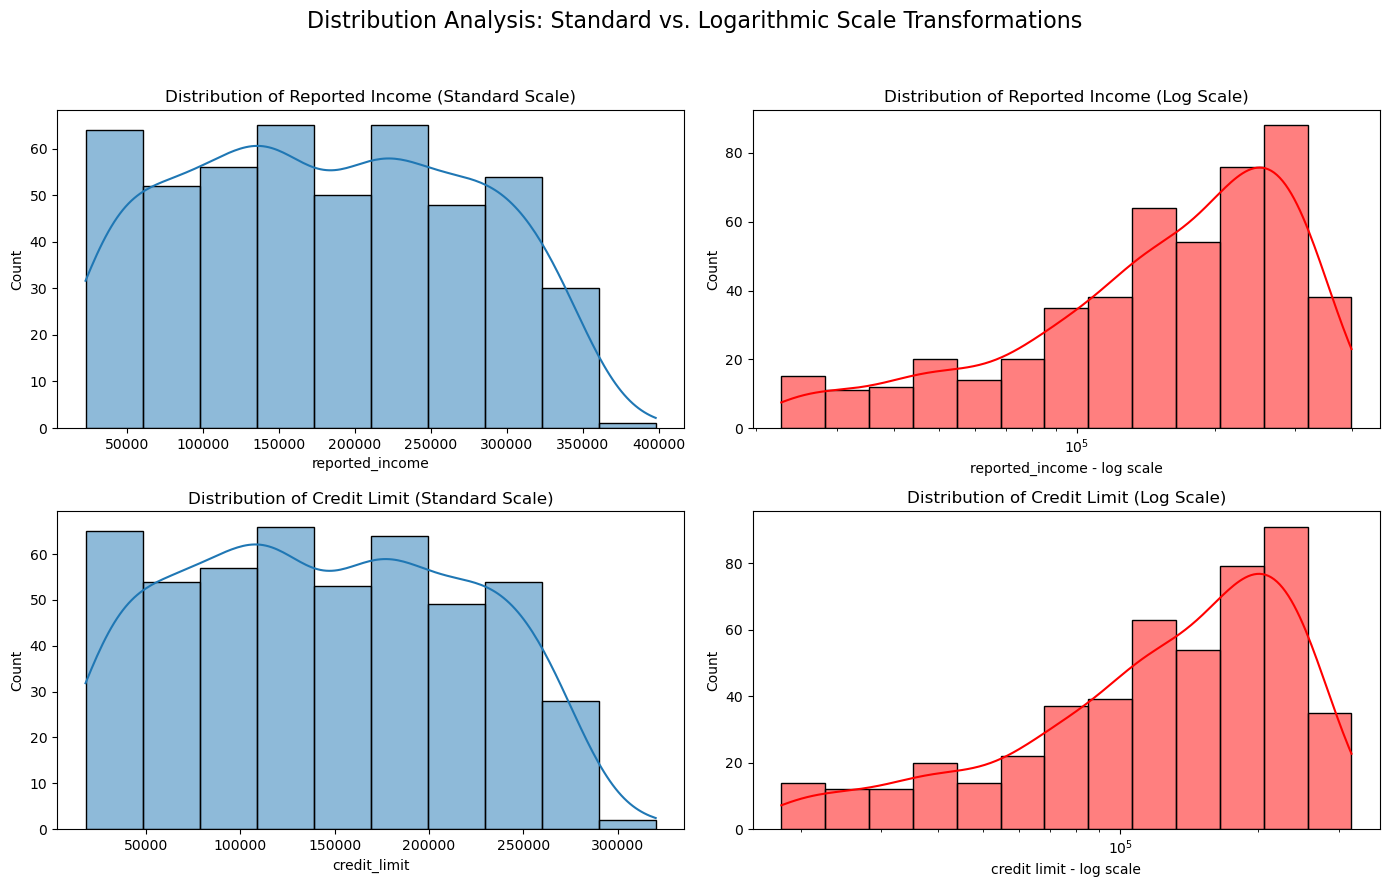

In [10]:
fig, ax = plt.subplots(2,2, figsize=[14,9])

sns.histplot(df['reported_income'], kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Distribution of Reported Income (Standard Scale)')

sns.histplot(df['reported_income'], kde=True, color='red', log_scale=True, ax=ax[0, 1])
ax[0, 1].set_title('Distribution of Reported Income (Log Scale)')
ax[0, 1].set_xlabel('reported_income - log scale')

sns.histplot(df['credit_limit'], kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Distribution of Credit Limit (Standard Scale)')

sns.histplot(df['credit_limit'], kde=True, color='red', log_scale=True, ax=ax[1, 1])
ax[1, 1].set_title('Distribution of Credit Limit (Log Scale)')
ax[1, 1].set_xlabel('credit limit - log scale')

plt.suptitle('Distribution Analysis: Standard vs. Logarithmic Scale Transformations', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Observation:** Both features exhibit a highly symmetric, approximately uniform distribution on a standard linear scale. Applying log transformations introduces severe artificial right-skewness. Consequently, features will remain on their standard scales in the production pipeline.

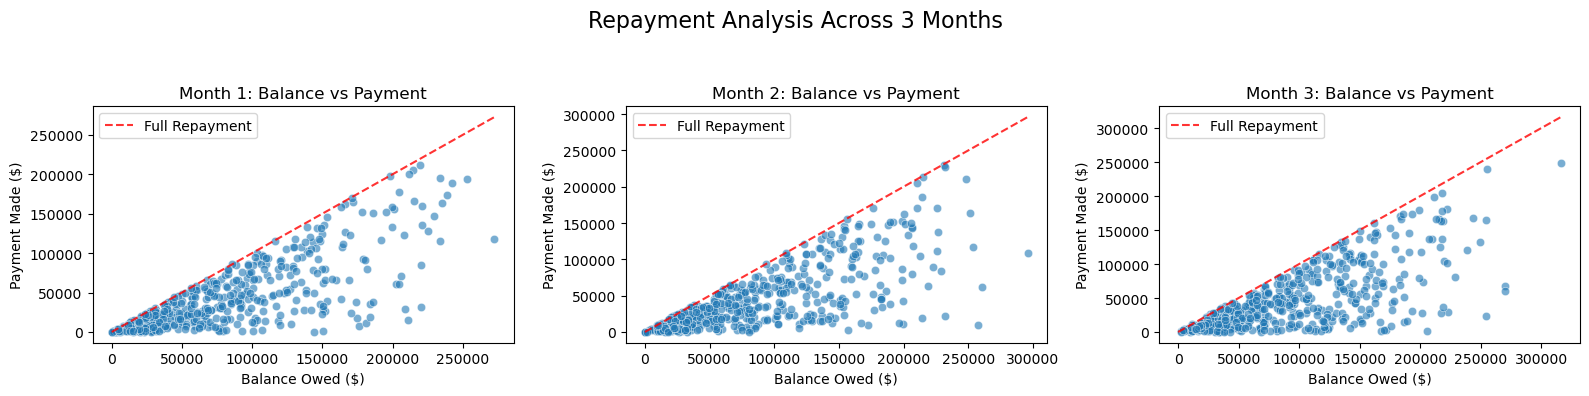

In [11]:
fig, ax = plt.subplots(1,3, figsize=[16,4])
months = [1, 2, 3]

for m in months:
    sns.scatterplot(data=df, x=f'balance_month_{m}', y=f'payment_month_{m}', alpha=0.6, ax=ax[m-1])
    max_value = max(df[f'balance_month_{m}'].max(), df[f'payment_month_{m}'].max())
    ax[m-1].plot([0, max_value], [0, max_value], color='red', linestyle='dashed', alpha=0.8, label='Full Repayment')
    ax[m-1].set_title(f'Month {m}: Balance vs Payment')
    ax[m-1].set_xlabel('Balance Owed ($)')
    ax[m-1].set_ylabel('Payment Made ($)')
    ax[m-1].legend()
    
plt.suptitle('Repayment Analysis Across 3 Months', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Credit Repayment Analytics

The 1x3 scatter grid tracks outstanding debt against repayment behavior over the three-month window. The red dashed line represents a 100% repayment rate ($\text{Payment} = \text{Balance}$).

#### Key Findings:
1. **Constraint Validation:** No data points cross above the $45^\circ$ baseline, confirming that monthly payments are logically capped by outstanding debt. Points resting directly on this line signify low-risk "Transactors" who clear their balances entirely each cycle.
2. **Visual Scale Compression:** A dense concentration of data points sits near the origin $(0,0)$, below $\$50,000$. While these represent low absolute financial loss (Loss Given Default), the wide scale of the axes compresses their visual variance. A healthy 50% partial payment looks identical to total non-payment at this scale.
3. **High-Risk Profiles:** Accounts drifting into the bottom-right quadrant represent severe risk: high balance accumulation paired with flat or near-zero payments.

#### Pipeline Implication:
To eliminate scale compression and allow the model to accurately differentiate repayment velocity at lower currency values, we will engineer a scale-invariant ratio:

$$\text{pay\_to\_bal\_ratio} = \frac{\text{payment\_month\_X}}{\text{balance\_month\_X}}$$

### Data Quality: Missing Credit Limit Imputation Strategy

Standard statistical imputation (mean/median) is unsuited for credit lines because it can create logical conflicts, such as setting a credit limit below a balance a customer has already actively carried.

**Business Rule Logic:** A customer's balance cannot exceed their credit limit. Therefore, the maximum balance observed across the three-month window (`balance_month_1` to `balance_month_3`) serves as a logically sound minimum proxy for a missing limit. If a customer holds a $\$0$ maximum balance, we will impute the missing value using the median.

*Note: Global calculations are performed below for prototyping visualization only. The production pipeline (`src/transformers.py`) will calculate the median strictly on the training split to prevent data leakage.*

In [12]:
max_historical_balances = df[['balance_month_1', 'balance_month_2', 'balance_month_3']].max(axis=1)
global_median_limit = df['credit_limit'].median()
imputation_values = max_historical_balances.replace(0, global_median_limit)
df['credit_limit'] = df['credit_limit'].fillna(imputation_values)

### Data Quality: Informative Missingness in Reported Income

Missing income values represent a severe risk signal, as omissions on credit applications are rarely missing at random. 

**Strategy:** We handle this column by applying median imputation to ensure downstream mathematical convergence, while simultaneously preserving the behavioral risk signal by creating a binary missingness flag (`income_was_missing`).

*Note: Global median calculation is used here for prototyping illustration only; the production pipeline will isolate this computation to the training split.*

In [13]:
df['income_was_missing'] = df['reported_income'].isna().astype(int)
df['reported_income'] = df['reported_income'].fillna(df['reported_income'].median())

In [14]:
df['income_was_missing']

0      0
1      0
2      0
3      0
4      0
      ..
495    0
496    1
497    0
498    0
499    0
Name: income_was_missing, Length: 500, dtype: int64

### Feature Engineering: Debt Accumulation Velocity

We capture the directional velocity of debt over the three months by subtracting the oldest month's balance from the most recent:

$$\text{balance\_trend} = \text{balance\_month\_3} - \text{balance\_month\_1}$$

* **Positive values** indicate expanding debt accumulation and potentially escalating credit risk.
* **Negative values** indicate steady principal repayment over time.

In [15]:
df['balance_trend'] = df['balance_month_3'] -  df['balance_month_1']

In [16]:
df['balance_trend']

0     -30411
1       8251
2      46655
3      28419
4      40612
       ...  
495    -8091
496    50311
497   -33586
498    -6240
499     -269
Name: balance_trend, Length: 500, dtype: int64

In [17]:
df.isna().sum()

reported_income       0
credit_limit          0
balance_month_1       0
payment_month_1       0
balance_month_2       0
payment_month_2       0
balance_month_3       0
payment_month_3       0
income_was_missing    0
balance_trend         0
dtype: int64